# PaliGemma from Scratch

**PaliGemma architecture** (SigLIP vision encoder + Gemma
language model + multimodal projector)
---
## 0. Setup


In [1]:
# Install dependencies (Colab-friendly)
!pip -q install torch torchvision datasets transformers pillow tqdm sentencepiece

In [2]:
from typing import Dict, List, Optional, Union, Tuple, Iterable
import os
import math
import json
import glob
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


---
## 1. SigLIP Vision Encoder

*( vision transformer that turns an image into patch embeddings.)*


In [3]:
class SiglipVisionConfig:
    def __init__(
        self,
        hidden_size=768,
        intermediate_size=3072,
        num_hidden_layers=12,
        num_attention_heads=12,
        num_channels=3,
        image_size=224,
        patch_size=16,
        layer_norm_eps=1e-6,
        attention_dropout=0.0,
        num_image_tokens: int = None,
        **kwargs
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.num_channels = num_channels
        self.patch_size = patch_size
        self.image_size = image_size
        self.attention_dropout = attention_dropout
        self.layer_norm_eps = layer_norm_eps
        self.num_image_tokens = num_image_tokens

In [4]:
class SiglipVisionEmbeddings(nn.Module):
    def __init__(self, config: SiglipVisionConfig):
        super().__init__()
        self.config = config
        self.embed_dim = config.hidden_size
        self.image_size = config.image_size
        self.patch_size = config.patch_size

        self.patch_embedding = nn.Conv2d(
            in_channels=config.num_channels,
            out_channels=self.embed_dim,
            kernel_size=self.patch_size,
            stride=self.patch_size,
            padding="valid",
        )

        self.num_patches = (self.image_size // self.patch_size) ** 2
        self.num_positions = self.num_patches
        self.position_embedding = nn.Embedding(self.num_positions, self.embed_dim)
        self.register_buffer(
            "position_ids",
            torch.arange(self.num_positions).expand((1, -1)),
            persistent=False,
        )

    def forward(self, pixel_values: torch.FloatTensor) -> torch.Tensor:
        _, _, height, width = pixel_values.shape
        patch_embeds = self.patch_embedding(pixel_values)
        embeddings = patch_embeds.flatten(2)
        embeddings = embeddings.transpose(1, 2)
        embeddings = embeddings + self.position_embedding(self.position_ids)
        return embeddings

In [5]:
class SiglipAttention(nn.Module):
    """Multi-headed attention from 'Attention Is All You Need' paper"""
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embed_dim = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.head_dim = self.embed_dim // self.num_heads
        self.scale = self.head_dim**-0.5
        self.dropout = config.attention_dropout

        self.k_proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.v_proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.q_proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.out_proj = nn.Linear(self.embed_dim, self.embed_dim)

    def forward(self, hidden_states: torch.Tensor):
        batch_size, seq_len, _ = hidden_states.size()
        query_states = self.q_proj(hidden_states)
        key_states = self.k_proj(hidden_states)
        value_states = self.v_proj(hidden_states)
        query_states = query_states.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        key_states = key_states.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        value_states = value_states.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        attn_weights = (torch.matmul(query_states, key_states.transpose(2, 3)) * self.scale)
        attn_weights = nn.functional.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query_states.dtype)
        attn_weights = nn.functional.dropout(attn_weights, p=self.dropout, training=self.training)
        attn_output = torch.matmul(attn_weights, value_states)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(batch_size, seq_len, self.embed_dim)
        attn_output = self.out_proj(attn_output)
        return attn_output, attn_weights

In [6]:
class SiglipMLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.fc1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.fc2 = nn.Linear(config.intermediate_size, config.hidden_size)

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        hidden_states = self.fc1(hidden_states)
        hidden_states = nn.functional.gelu(hidden_states, approximate="tanh")
        hidden_states = self.fc2(hidden_states)
        return hidden_states

In [7]:
class SiglipEncoderLayer(nn.Module):
    def __init__(self, config: SiglipVisionConfig):
        super().__init__()
        self.embed_dim = config.hidden_size
        self.self_attn = SiglipAttention(config)
        self.layer_norm1 = nn.LayerNorm(self.embed_dim, eps=config.layer_norm_eps)
        self.mlp = SiglipMLP(config)
        self.layer_norm2 = nn.LayerNorm(self.embed_dim, eps=config.layer_norm_eps)

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        residual = hidden_states
        hidden_states = self.layer_norm1(hidden_states)
        hidden_states, _ = self.self_attn(hidden_states=hidden_states)
        hidden_states = residual + hidden_states
        residual = hidden_states
        hidden_states = self.layer_norm2(hidden_states)
        hidden_states = self.mlp(hidden_states)
        hidden_states = residual + hidden_states
        return hidden_states

In [8]:
class SiglipEncoder(nn.Module):
    def __init__(self, config: SiglipVisionConfig):
        super().__init__()
        self.config = config
        self.layers = nn.ModuleList(
            [SiglipEncoderLayer(config) for _ in range(config.num_hidden_layers)]
        )

    def forward(self, inputs_embeds: torch.Tensor) -> torch.Tensor:
        hidden_states = inputs_embeds
        for encoder_layer in self.layers:
            hidden_states = encoder_layer(hidden_states)
        return hidden_states

In [9]:
class SiglipVisionTransformer(nn.Module):
    def __init__(self, config: SiglipVisionConfig):
        super().__init__()
        self.config = config
        embed_dim = config.hidden_size
        self.embeddings = SiglipVisionEmbeddings(config)
        self.encoder = SiglipEncoder(config)
        self.post_layernorm = nn.LayerNorm(embed_dim, eps=config.layer_norm_eps)

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        hidden_states = self.embeddings(pixel_values)
        last_hidden_state = self.encoder(inputs_embeds=hidden_states)
        last_hidden_state = self.post_layernorm(last_hidden_state)
        return last_hidden_state

In [10]:
class SiglipVisionModel(nn.Module):
    def __init__(self, config: SiglipVisionConfig):
        super().__init__()
        self.config = config
        self.vision_model = SiglipVisionTransformer(config)

    def forward(self, pixel_values) -> Tuple:
        return self.vision_model(pixel_values=pixel_values)

---
## 2. Image Processing

*( — resize / rescale / normalize, and prepend `<image>` tokens.)*


In [11]:
IMAGENET_STANDARD_MEAN = [0.5, 0.5, 0.5]
IMAGENET_STANDARD_STD = [0.5, 0.5, 0.5]

def resize(image, size, resample=None, reducing_gap=None):
    height, width = size
    return image.resize((width, height), resample=resample, reducing_gap=reducing_gap)

def rescale(image: np.ndarray, scale: float, dtype: np.dtype = np.float32) -> np.ndarray:
    return (image * scale).astype(dtype)

def normalize(image, mean, std):
    mean = np.array(mean, dtype=image.dtype)
    std = np.array(std, dtype=image.dtype)
    return (image - mean) / std

def process_images(images, size=None, resample=None, rescale_factor=None,
                   image_mean=None, image_std=None):
    height, width = size[0], size[1]
    images = [resize(image=img, size=(height, width), resample=resample) for img in images]
    images = [np.array(img) for img in images]
    images = [rescale(img, scale=rescale_factor) for img in images]
    images = [normalize(img, mean=image_mean, std=image_std) for img in images]
    images = [img.transpose(2, 0, 1) for img in images]
    return images

def add_image_tokens_to_prompt(prefix_prompt, bos_token, image_seq_len, image_token):
    return f"{image_token * image_seq_len}{bos_token}{prefix_prompt}\n"

In [12]:
class PaliGemmaProcessor:
    IMAGE_TOKEN = "<image>"

    def __init__(self, tokenizer, num_image_tokens: int, image_size: int):
        super().__init__()
        self.image_seq_length = num_image_tokens
        self.image_size = image_size

        tokens_to_add = {"additional_special_tokens": [self.IMAGE_TOKEN]}
        tokenizer.add_special_tokens(tokens_to_add)
        EXTRA_TOKENS = [f"<loc{i:04d}>" for i in range(1024)]
        EXTRA_TOKENS += [f"<seg{i:03d}>" for i in range(128)]
        tokenizer.add_tokens(EXTRA_TOKENS)
        self.image_token_id = tokenizer.convert_tokens_to_ids(self.IMAGE_TOKEN)
        tokenizer.add_bos_token = False
        tokenizer.add_eos_token = False
        self.tokenizer = tokenizer

    def __call__(self, text, images, padding="longest", truncation=True):
        assert len(images) == 1 and len(text) == 1, f"Received {len(images)} images for {len(text)} prompts."
        pixel_values = process_images(
            images,
            size=(self.image_size, self.image_size),
            resample=Image.Resampling.BICUBIC,
            rescale_factor=1 / 255.0,
            image_mean=IMAGENET_STANDARD_MEAN,
            image_std=IMAGENET_STANDARD_STD,
        )
        pixel_values = np.stack(pixel_values, axis=0)
        pixel_values = torch.tensor(pixel_values)
        input_strings = [
            add_image_tokens_to_prompt(
                prefix_prompt=prompt,
                bos_token=self.tokenizer.bos_token,
                image_seq_len=self.image_seq_length,
                image_token=self.IMAGE_TOKEN,
            )
            for prompt in text
        ]
        inputs = self.tokenizer(input_strings, return_tensors="pt", padding=padding, truncation=truncation)
        return {"pixel_values": pixel_values, **inputs}

---
## 3. Gemma Language Model

*( — RMSNorm, rotary embeddings, grouped-query attention,
KV cache, decoder layers.)*


In [13]:
class GemmaConfig():
    def __init__(self, vocab_size, hidden_size, intermediate_size, num_hidden_layers,
                 num_attention_heads, num_key_value_heads, head_dim=256,
                 max_position_embeddings=8192, rms_norm_eps=1e-6, rope_theta=10000.0,
                 attention_bias=False, attention_dropout=0.0, pad_token_id=None, **kwargs):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_position_embeddings = max_position_embeddings
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.head_dim = head_dim
        self.num_key_value_heads = num_key_value_heads
        self.rms_norm_eps = rms_norm_eps
        self.rope_theta = rope_theta
        self.attention_bias = attention_bias
        self.attention_dropout = attention_dropout
        self.pad_token_id = pad_token_id

In [14]:
class PaliGemmaConfig():
    def __init__(self, vision_config=None, text_config=None, ignore_index=-100,
                 image_token_index=256000, vocab_size=257152, projection_dim=2048,
                 hidden_size=2048, pad_token_id=None, **kwargs):
        super().__init__()
        self.ignore_index = ignore_index
        self.image_token_index = image_token_index
        self.vocab_size = vocab_size
        self.projection_dim = projection_dim
        self.hidden_size = hidden_size
        self.is_encoder_decoder = False
        self.pad_token_id = pad_token_id

        self.vision_config = SiglipVisionConfig(**vision_config)
        self.text_config = GemmaConfig(**text_config, pad_token_id=pad_token_id)
        self.vocab_size = self.text_config.vocab_size
        self.text_config.num_image_tokens = (self.vision_config.image_size // self.vision_config.patch_size) ** 2
        self.vision_config.projection_dim = projection_dim

In [15]:
class KVCache():
    def __init__(self) -> None:
        self.key_cache: List[torch.Tensor] = []
        #B,1,5,64
        self.value_cache: List[torch.Tensor] = []
        #B,1,5,64

    def num_items(self) -> int:
        if len(self.key_cache) == 0:
            return 0
        return self.key_cache[0].shape[-2]
        #b,num_kv_heads,tokens,headdim
        #1,1,4,64

    def update(self, key_states, value_states, layer_idx):
        if len(self.key_cache) <= layer_idx:
            self.key_cache.append(key_states)
            self.value_cache.append(value_states)
        else:
            self.key_cache[layer_idx] = torch.cat([self.key_cache[layer_idx], key_states], dim=-2)
            self.value_cache[layer_idx] = torch.cat([self.value_cache[layer_idx], value_states], dim=-2)
        return self.key_cache[layer_idx], self.value_cache[layer_idx]

def repeat_kv(hidden_states: torch.Tensor, n_rep: int) -> torch.Tensor:
    batch, num_key_value_heads, slen, head_dim = hidden_states.shape
    if n_rep == 1:
        return hidden_states
    hidden_states = hidden_states[:, :, None, :, :].expand(batch, num_key_value_heads, n_rep, slen, head_dim)
    return hidden_states.reshape(batch, num_key_value_heads * n_rep, slen, head_dim)

In [16]:
class GemmaRMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.zeros(dim))

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)

    def forward(self, x):
        output = self._norm(x.float())
        output = output * (1.0 + self.weight.float())
        return output.type_as(x)

In [17]:
class GemmaRotaryEmbedding(nn.Module):
    def __init__(self, dim, max_position_embeddings=2048, base=10000, device=None):
        super().__init__()
        self.dim = dim
        self.max_position_embeddings = max_position_embeddings
        self.base = base
        inv_freq = 1.0 / (self.base ** (torch.arange(0, self.dim, 2, dtype=torch.int64).float() / self.dim))
        self.register_buffer("inv_freq", tensor=inv_freq, persistent=False)

    @torch.no_grad()
    def forward(self, x, position_ids, seq_len=None):
        self.inv_freq.to(x.device)
        #B,T
        #inv_freq dim/2
        inv_freq_expanded = self.inv_freq[None, :, None].float().expand(position_ids.shape[0], -1, 1)
        #inv_freq [1,dim/2,1]
         #inv_freq [b,dim/2,1]

        #position_ids:  [b,t]
        #position_ids:  [b,1,t]
        position_ids_expanded = position_ids[:, None, :].float()
        device_type = x.device.type
        device_type = device_type if isinstance(device_type, str) and device_type != "mps" else "cpu"

        with torch.autocast(device_type=device_type, enabled=False):
            freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
            #b,Seq_Len, Head_Dim / 2

            emb = torch.cat((freqs, freqs), dim=-1)
            #b,Seq_Len, Head_Dim
            cos = emb.cos()
            sin = emb.sin()
        return cos.to(dtype=x.dtype), sin.to(dtype=x.dtype)
        #b,Seq_Len, Head_Dim

def rotate_half(x):
    #[0,1,2,........64]
    x1 = x[..., : x.shape[-1] // 2]

    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)

def apply_rotary_pos_emb(q, k, cos, sin, unsqueeze_dim=1):
  #b,Seq_Len, Head_Dim
  #B,6,T,64
    cos = cos.unsqueeze(unsqueeze_dim)
    #b,1,Seq_Len, Head_Dim
    sin = sin.unsqueeze(unsqueeze_dim)
    #b,1,Seq_Len, Head_Dim
    q_embed = (q * cos) + (rotate_half(q) * sin)
    k_embed = (k * cos) + (rotate_half(k) * sin)
    return q_embed, k_embed

In [18]:
class GemmaAttention(nn.Module):
    def __init__(self, config: GemmaConfig, layer_idx: Optional[int] = None):
        super().__init__()
        self.config = config
        self.layer_idx = layer_idx
        self.attention_dropout = config.attention_dropout
        self.hidden_size = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.head_dim = config.head_dim
        self.num_key_value_heads = config.num_key_value_heads
        self.num_key_value_groups = self.num_heads // self.num_key_value_heads
        self.max_position_embeddings = config.max_position_embeddings
        self.rope_theta = config.rope_theta
        self.is_causal = True
        assert self.hidden_size % self.num_heads == 0

        self.q_proj = nn.Linear(self.hidden_size, self.num_heads * self.head_dim, bias=config.attention_bias)
        self.k_proj = nn.Linear(self.hidden_size, self.num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.v_proj = nn.Linear(self.hidden_size, self.num_key_value_heads * self.head_dim, bias=config.attention_bias)
        self.o_proj = nn.Linear(self.num_heads * self.head_dim, self.hidden_size, bias=config.attention_bias)
        self.rotary_emb = GemmaRotaryEmbedding(self.head_dim,
            max_position_embeddings=self.max_position_embeddings, base=self.rope_theta)

    def forward(self, hidden_states, attention_mask=None, position_ids=None, kv_cache=None, **kwargs):
        bsz, q_len, _ = hidden_states.size()
        query_states = self.q_proj(hidden_states)
        #b, t,384
        key_states = self.k_proj(hidden_states)
        #b, t,64
        value_states = self.v_proj(hidden_states)
        #b, t,64
        query_states = query_states.view(bsz, q_len, self.num_heads, self.head_dim).transpose(1, 2)
        #B,6,T,64
        key_states = key_states.view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        #B,1,T,64
        value_states = value_states.view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        #B,1,T,64

        cos, sin = self.rotary_emb(value_states, position_ids, seq_len=None)
        query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if kv_cache is not None:
            key_states, value_states = kv_cache.update(key_states, value_states, self.layer_idx)

        key_states = repeat_kv(key_states, self.num_key_value_groups)
        value_states = repeat_kv(value_states, self.num_key_value_groups)
        attn_weights = torch.matmul(query_states, key_states.transpose(2, 3)) / math.sqrt(self.head_dim)

        assert attention_mask is not None
        attn_weights = attn_weights + attention_mask
        attn_weights = nn.functional.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query_states.dtype)
        attn_weights = nn.functional.dropout(attn_weights, p=self.attention_dropout, training=self.training)
        attn_output = torch.matmul(attn_weights, value_states)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(bsz, q_len, -1)
        attn_output = self.o_proj(attn_output)
        return attn_output, attn_weights

In [19]:
class GemmaMLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.intermediate_size = config.intermediate_size
        self.gate_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=False)
        self.up_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=False)
        self.down_proj = nn.Linear(self.intermediate_size, self.hidden_size, bias=False)

    def forward(self, x):
        return self.down_proj(nn.functional.gelu(self.gate_proj(x), approximate="tanh") * self.up_proj(x))

In [20]:
class GemmaDecoderLayer(nn.Module):
    def __init__(self, config: GemmaConfig, layer_idx: int):
        super().__init__()
        self.hidden_size = config.hidden_size
        self.self_attn = GemmaAttention(config=config, layer_idx=layer_idx)
        self.mlp = GemmaMLP(config)
        self.input_layernorm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)
        self.post_attention_layernorm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def forward(self, hidden_states, attention_mask=None, position_ids=None, kv_cache=None):
        residual = hidden_states
        hidden_states = self.input_layernorm(hidden_states)
        hidden_states, _ = self.self_attn(
            hidden_states=hidden_states, attention_mask=attention_mask,
            position_ids=position_ids, kv_cache=kv_cache)
        hidden_states = residual + hidden_states
        residual = hidden_states
        hidden_states = self.post_attention_layernorm(hidden_states)
        hidden_states = self.mlp(hidden_states)
        hidden_states = residual + hidden_states
        return hidden_states

In [21]:
class GemmaModel(nn.Module):
    def __init__(self, config: GemmaConfig):
        super().__init__()
        self.config = config
        self.padding_idx = config.pad_token_id
        self.vocab_size = config.vocab_size
        self.embed_tokens = nn.Embedding(config.vocab_size, config.hidden_size, self.padding_idx)
        self.layers = nn.ModuleList(
            [GemmaDecoderLayer(config, layer_idx) for layer_idx in range(config.num_hidden_layers)])
        self.norm = GemmaRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

    def get_input_embeddings(self):
        return self.embed_tokens

    def forward(self, attention_mask=None, position_ids=None, inputs_embeds=None, kv_cache=None):
        hidden_states = inputs_embeds
        normalizer = torch.tensor(self.config.hidden_size**0.5, dtype=hidden_states.dtype)
        hidden_states = hidden_states * normalizer
        for decoder_layer in self.layers:
            hidden_states = decoder_layer(hidden_states, attention_mask=attention_mask,
                                          position_ids=position_ids, kv_cache=kv_cache)
        hidden_states = self.norm(hidden_states)
        return hidden_states

In [22]:
class GemmaForCausalLM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.model = GemmaModel(config)
        self.vocab_size = config.vocab_size
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)

    def get_input_embeddings(self):
        return self.model.embed_tokens

    def tie_weights(self):
        self.lm_head.weight = self.model.embed_tokens.weight

    def forward(self, attention_mask=None, position_ids=None, inputs_embeds=None, kv_cache=None):
        outputs = self.model(attention_mask=attention_mask, position_ids=position_ids,
                             inputs_embeds=inputs_embeds, kv_cache=kv_cache)
        hidden_states = outputs
        logits = self.lm_head(hidden_states)
        logits = logits.float()
        return_data = {"logits": logits}
        if kv_cache is not None:
            return_data["kv_cache"] = kv_cache
        return return_data

In [23]:
class PaliGemmaMultiModalProjector(nn.Module):
    def __init__(self, config: PaliGemmaConfig):
        super().__init__()
        self.linear = nn.Linear(config.vision_config.hidden_size,
                                config.vision_config.projection_dim, bias=True)

    def forward(self, image_features):
        return self.linear(image_features)

---


- It accepts an optional `labels` tensor and computes the **causal-LM loss**.
- It builds the **PaliGemma prefix-LM attention mask**: the image tokens + prefix prompt
  attend to each other **bidirectionally**, while the generated caption (suffix) is **causal**.
  This is exactly how PaliGemma is trained.
- It supports **padding** (needed for batching variable-length captions), masking pad
  positions out of both attention and the loss.




In [24]:
class PaliGemmaForConditionalGeneration(nn.Module):
    def __init__(self, config: PaliGemmaConfig):
        super().__init__()
        self.config = config
        self.vision_tower = SiglipVisionModel(config.vision_config)
        self.multi_modal_projector = PaliGemmaMultiModalProjector(config)
        self.vocab_size = config.vocab_size
        self.language_model = GemmaForCausalLM(config.text_config)
        self.pad_token_id = self.config.pad_token_id if self.config.pad_token_id is not None else -1

    def tie_weights(self):
        return self.language_model.tie_weights()

    def get_input_embeddings(self):
        return self.language_model.get_input_embeddings()

    def _merge_input_ids_with_image_features(
        self, image_features, inputs_embeds, input_ids, attention_mask, kv_cache=None
    ):
        _, _, embed_dim = image_features.shape
        batch_size, sequence_length = input_ids.shape
        # Keep every tensor in the same dtype as the (possibly autocast/bf16) image features,
        # otherwise masked_scatter fails with "expected self and source to have same dtypes".
        target_dtype, device = image_features.dtype, inputs_embeds.device
        inputs_embeds = inputs_embeds.to(target_dtype)
        scaled_image_features = image_features / (self.config.hidden_size**0.5)

        final_embedding = torch.zeros(batch_size, sequence_length, embed_dim,
                                      dtype=target_dtype, device=device)
        text_mask = (input_ids != self.config.image_token_index) & (input_ids != self.pad_token_id)
        image_mask = input_ids == self.config.image_token_index
        pad_mask = input_ids == self.pad_token_id

        text_mask_expanded = text_mask.unsqueeze(-1).expand(-1, -1, embed_dim)
        pad_mask_expanded = pad_mask.unsqueeze(-1).expand(-1, -1, embed_dim)
        image_mask_expanded = image_mask.unsqueeze(-1).expand(-1, -1, embed_dim)

        final_embedding = torch.where(text_mask_expanded, inputs_embeds, final_embedding)
        final_embedding = final_embedding.masked_scatter(image_mask_expanded, scaled_image_features)
        final_embedding = torch.where(pad_mask_expanded, torch.zeros_like(final_embedding), final_embedding)

        dtype = target_dtype
        min_dtype = torch.finfo(dtype).min
        q_len = inputs_embeds.shape[1]

        if kv_cache is None or kv_cache.num_items() == 0:
            # ---- TRAINING / PREFILL ----
            # PaliGemma prefix-LM mask:
            #   * image + prefix tokens (everything that is NOT the suffix) attend bidirectionally
            #   * suffix (caption) tokens are causal
            # We also forbid attending to PAD positions.
            #
            # We mark suffix tokens with `is_suffix` (passed via attention_mask trick below is
            # not enough), so during training we pass an explicit `token_type_ids`-like signal
            # through `attention_mask` semantics. To keep the signature unchanged we rebuild the
            # mask here from `input_ids`: pad is known; for the prefix/suffix split we rely on the
            # boolean buffer set on the module (self._suffix_mask) when training.
            pad_2d = (input_ids != self.pad_token_id)  # [B, L] True where real token

            if getattr(self, "_suffix_mask", None) is not None:
                is_suffix = self._suffix_mask.to(device)          # [B, L] True for caption tokens
            else:
                is_suffix = torch.zeros_like(input_ids, dtype=torch.bool)

            # causal[i, j] = j <= i
            causal = torch.tril(torch.ones((q_len, q_len), dtype=torch.bool, device=device))
            causal = causal.unsqueeze(0).expand(batch_size, -1, -1)            # [B, L, L]

            is_suffix_q = is_suffix.unsqueeze(-1)                              # [B, L, 1] (query)
            # If the QUERY token is a prefix/image token -> it may attend to all prefix tokens
            # (bidirectional), i.e. allow j whenever key is a prefix token.
            is_prefix_k = (~is_suffix).unsqueeze(1)                            # [B, 1, L] (key)
            allowed = torch.where(is_suffix_q, causal, is_prefix_k.expand(-1, q_len, -1))

            # Forbid attending to padding keys
            allowed = allowed & pad_2d.unsqueeze(1)                            # [B, L, L]
            causal_mask = torch.zeros((batch_size, q_len, q_len), dtype=dtype, device=device)
            causal_mask = causal_mask.masked_fill(~allowed, min_dtype)
        else:
            # ---- INFERENCE (token-by-token generation) ----
            assert q_len == 1
            kv_len = kv_cache.num_items() + q_len
            causal_mask = torch.full((batch_size, q_len, kv_len), fill_value=0,
                                     dtype=dtype, device=device)

        causal_mask = causal_mask.unsqueeze(1)  # add head dim

        if kv_cache is not None and kv_cache.num_items() > 0:
            position_ids = attention_mask.cumsum(-1)[:, -1]
            if position_ids.dim() == 1:
                position_ids = position_ids.unsqueeze(0)
        else:
            position_ids = (attention_mask.cumsum(-1)).masked_fill_((attention_mask == 0), 1).to(device)

        return final_embedding, causal_mask, position_ids

    def forward(self, input_ids=None, pixel_values=None, attention_mask=None,
                kv_cache=None, labels=None, suffix_mask=None):
        # `suffix_mask`: [B, L] bool, True for caption(suffix) tokens. Used only in training
        # to build the prefix-LM attention mask. Stored on the module so the merge fn can see it.
        self._suffix_mask = suffix_mask

        inputs_embeds = self.language_model.get_input_embeddings()(input_ids)
        selected_image_feature = self.vision_tower(pixel_values.to(inputs_embeds.dtype))
        image_features = self.multi_modal_projector(selected_image_feature)

        inputs_embeds, attn_mask_4d, position_ids = self._merge_input_ids_with_image_features(
            image_features, inputs_embeds, input_ids, attention_mask, kv_cache)

        outputs = self.language_model(
            attention_mask=attn_mask_4d, position_ids=position_ids,
            inputs_embeds=inputs_embeds, kv_cache=kv_cache)

        logits = outputs["logits"]
        loss = None
        if labels is not None:
            # Standard next-token shift: predict token t+1 from position t.
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss_fct = CrossEntropyLoss(ignore_index=self.config.ignore_index)
            loss = loss_fct(shift_logits.view(-1, shift_logits.size(-1)),
                            shift_labels.view(-1))

        result = {"logits": logits, "loss": loss}
        if kv_cache is not None:
            result["kv_cache"] = outputs.get("kv_cache", kv_cache)
        return result

**postions: 0, 1,2,3,4**

**tokens: a , cat, sat ,down ,eos**

**labels: cat,sat,down,eos**

---
## 5. Build a small-but-real config (trainable from scratch on one GPU)

Same classes as `paligemma-3b`, just smaller numbers. This is the only thing standing between
"toy that trains in an hour" and "3B model that needs a cluster". Bump these up if you have
more compute.


In [25]:
def build_tiny_config(vocab_size: int, pad_token_id: int, image_token_index: int):
    """Same architecture as paligemma-3b, scaled down to train from scratch on 1 GPU."""
    vision_config = dict(
        hidden_size=384,          # (3b uses 1152)
        intermediate_size=1536,
        num_hidden_layers=6,      # (3b uses 27)
        num_attention_heads=6,
        num_channels=3,
        image_size=224,
        patch_size=16,            # -> (224/16)^2 = 196 image tokens
        layer_norm_eps=1e-6,
        attention_dropout=0.0,
    )
    text_config = dict(
        vocab_size=vocab_size,
        hidden_size=384,          # MUST match projection_dim (image features are projected to this)
        intermediate_size=1536,
        num_hidden_layers=6,      # (3b uses 18)
        num_attention_heads=6,
        num_key_value_heads=1,    # grouped-query attention
        head_dim=64,
        max_position_embeddings=512,
        rms_norm_eps=1e-6,
        rope_theta=10000.0,
        attention_bias=False,
        attention_dropout=0.0,
    )
    config = PaliGemmaConfig(
        vision_config=vision_config,
        text_config=text_config,
        ignore_index=-100,
        image_token_index=image_token_index,
        vocab_size=vocab_size,
        projection_dim=384,       # must equal text hidden_size
        hidden_size=384,
        pad_token_id=pad_token_id,
    )
    return config

---
## 6. Tokenizer

We reuse the Gemma tokenizer **vocabulary only** (so text is tokenized sensibly) but we do
**not** load any pretrained model weights — the embedding table and every weight is randomly
initialized and learned from scratch. If you prefer zero dependence on Google's tokenizer,
swap in any `AutoTokenizer` (e.g. `gpt2`); the code below only needs `bos`, `eos`, `pad`.


In [26]:
from transformers import AutoTokenizer

# Gemma tokenizer (vocab only; NO model weights are downloaded here).
# If this gate-locked repo asks for login, either run huggingface_hub.login(...) OR
# replace with: AutoTokenizer.from_pretrained("gpt2") and set pad/bos/eos as below.
try:
    base_tokenizer = AutoTokenizer.from_pretrained("google/paligemma-3b-pt-224")
except Exception as e:
    print("Falling back to gpt2 tokenizer because:", repr(e))
    base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
    base_tokenizer.add_special_tokens({"bos_token": "<bos>", "eos_token": "<eos>", "pad_token": "<pad>"})

if base_tokenizer.pad_token is None:
    base_tokenizer.add_special_tokens({"pad_token": "<pad>"})
if base_tokenizer.bos_token is None:
    base_tokenizer.add_special_tokens({"bos_token": "<bos>"})
if base_tokenizer.eos_token is None:
    base_tokenizer.add_special_tokens({"eos_token": "<eos>"})

IMAGE_SIZE = 224
PATCH_SIZE = 16
NUM_IMAGE_TOKENS = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 196

# The processor adds the <image>, <locNNNN>, <segNNN> special tokens to the tokenizer.
processor = PaliGemmaProcessor(base_tokenizer, num_image_tokens=NUM_IMAGE_TOKENS, image_size=IMAGE_SIZE)
tokenizer = processor.tokenizer

PAD_ID = tokenizer.pad_token_id
BOS_ID = tokenizer.bos_token_id
EOS_ID = tokenizer.eos_token_id
IMAGE_TOKEN_ID = processor.image_token_id
VOCAB_SIZE = len(tokenizer)

print("vocab size:", VOCAB_SIZE, "| pad:", PAD_ID, "| bos:", BOS_ID, "| eos:", EOS_ID,
      "| <image> id:", IMAGE_TOKEN_ID)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Falling back to gpt2 tokenizer because: OSError('You are trying to access a gated repo.\nMake sure to have access to it at https://huggingface.co/google/paligemma-3b-pt-224.\n401 Client Error. (Request ID: Root=1-6a40f0ea-5d02a1542843b7ff057765c3;7dd399b5-f308-472c-b6e2-17961f89ced6)\n\nCannot access gated repo for url https://huggingface.co/google/paligemma-3b-pt-224/resolve/main/config.json.\nAccess to model google/paligemma-3b-pt-224 is restricted. You must have access to it and be authenticated to access it. Please log in.')


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

vocab size: 51413 | pad: 50259 | bos: 50257 | eos: 50258 | <image> id: 50260


---
## 7. Dataset — Flickr8k (real images + human captions)

We stream the professional **Flickr8k** image-captioning dataset from the Hugging Face Hub
(`jxie/flickr8k`). Each example is an image with up to 5 human-written captions. We build the
exact PaliGemma training sequence:

```
[<image> x 196] [bos] <task prompt> \n  | <caption tokens> <eos>
\_________ prefix (bidirectional) _____/   \____ suffix (causal) ____/
```

The **labels** are `-100` (ignored) on the image + prefix part, and equal to the caption token
ids on the suffix part — so the model is only trained to predict the caption, not the prompt.


In [27]:
from datasets import load_dataset

# Real, professional captioning dataset. ~8k images, 5 captions each.
# This downloads & caches automatically on first run.
raw = load_dataset("jxie/flickr8k")
print(raw)

# The dataset exposes columns like: image, caption_0 ... caption_4 (schema can vary slightly).
# We normalize each split into a flat list of (image, caption) pairs.
def flatten_split(split):
    cols = split.column_names
    caption_cols = [c for c in cols if c.lower().startswith("caption")]
    if not caption_cols:
        # some versions use a single "caption" list column
        caption_cols = ["caption"] if "caption" in cols else []
    return split, caption_cols

train_split, cap_cols = flatten_split(raw["train"])
print("caption columns:", cap_cols)

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})
caption columns: ['caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']


In [28]:
TASK_PROMPT = "caption en"   # PaliGemma-style task prefix for English captioning
MAX_LEN = 320                # 196 image + bos + short prompt + caption + eos fits comfortably

class Flickr8kCaptionDataset(Dataset):
    """Yields fully-built (input_ids, labels, suffix_mask, pixel_values) for one (image, caption)."""
    def __init__(self, hf_split, caption_cols, processor, task_prompt=TASK_PROMPT, max_len=MAX_LEN):
        self.ds = hf_split
        self.caption_cols = caption_cols
        self.processor = processor
        self.tokenizer = processor.tokenizer
        self.task_prompt = task_prompt
        self.max_len = max_len
        self.image_seq_len = processor.image_seq_length
        self.image_token_id = processor.image_token_id

        # Build an index of (row_idx, caption_col) so every caption is a training example.
        self.index = []
        for i in range(len(self.ds)):
            for c in self.caption_cols:
                self.index.append((i, c))

    def __len__(self):
        return len(self.index)

    def _get_caption(self, row, col):
        val = row[col]
        if isinstance(val, list):
            val = val[0] if val else ""
        return str(val).strip()

    def __getitem__(self, idx):
        row_idx, col = self.index[idx]
        row = self.ds[row_idx]
        image = row["image"]
        if not isinstance(image, Image.Image):
            image = Image.open(image)
        image = image.convert("RGB")
        caption = self._get_caption(row, col)

        # --- pixel values (same preprocessing as the processor) ---
        px = process_images([image], size=(self.processor.image_size, self.processor.image_size),
                            resample=Image.Resampling.BICUBIC, rescale_factor=1/255.0,
                            image_mean=IMAGENET_STANDARD_MEAN, image_std=IMAGENET_STANDARD_STD)
        pixel_values = torch.tensor(np.stack(px, axis=0))[0]  # [C,H,W]

        # --- token sequence ---
        # prefix = [<image> * N] [bos] <task prompt> \n
        image_ids = [self.image_token_id] * self.image_seq_len
        prefix_text = f"{self.task_prompt}\n"
        prefix_text_ids = self.tokenizer(prefix_text, add_special_tokens=False)["input_ids"]
        prefix_ids = image_ids + [BOS_ID] + prefix_text_ids

        # suffix = <caption tokens> <eos>
        suffix_ids = self.tokenizer(caption, add_special_tokens=False)["input_ids"] + [EOS_ID]

        input_ids = prefix_ids + suffix_ids
        # labels: ignore prefix, learn suffix
        labels = [-100] * len(prefix_ids) + list(suffix_ids)
        # suffix_mask: True on suffix positions (caption); False on image+prefix
        suffix_mask = [False] * len(prefix_ids) + [True] * len(suffix_ids)

        # truncate (rare with short captions)
        input_ids = input_ids[:self.max_len]
        labels = labels[:self.max_len]
        suffix_mask = suffix_mask[:self.max_len]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "suffix_mask": torch.tensor(suffix_mask, dtype=torch.bool),
            "pixel_values": pixel_values,
        }

In [29]:
def collate_fn(batch):
    """Right-pad a batch to equal length. Pad ids -> PAD_ID, labels -> -100, suffix -> False."""
    maxlen = max(x["input_ids"].size(0) for x in batch)
    input_ids, labels, suffix_mask, attn, pixels = [], [], [], [], []
    for x in batch:
        L = x["input_ids"].size(0)
        pad = maxlen - L
        input_ids.append(torch.cat([x["input_ids"], torch.full((pad,), PAD_ID, dtype=torch.long)]))
        labels.append(torch.cat([x["labels"], torch.full((pad,), -100, dtype=torch.long)]))
        suffix_mask.append(torch.cat([x["suffix_mask"], torch.zeros(pad, dtype=torch.bool)]))
        attn.append(torch.cat([torch.ones(L, dtype=torch.long), torch.zeros(pad, dtype=torch.long)]))
        pixels.append(x["pixel_values"])
    return {
        "input_ids": torch.stack(input_ids),
        "labels": torch.stack(labels),
        "suffix_mask": torch.stack(suffix_mask),
        "attention_mask": torch.stack(attn),
        "pixel_values": torch.stack(pixels),
    }

---
## 8. Instantiate the model from scratch

Random init — no pretrained weights are loaded. We tie the LM head to the input embeddings
(standard for Gemma) and print the parameter count.


In [30]:
config = build_tiny_config(vocab_size=VOCAB_SIZE, pad_token_id=PAD_ID,
                           image_token_index=IMAGE_TOKEN_ID)

model = PaliGemmaForConditionalGeneration(config)
model.tie_weights()                 # lm_head shares weights with token embeddings
model.to(DEVICE)

# Make sure the embedding table covers the special tokens the processor added.
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params/1e6:.1f}M")
print("Image token id:", config.image_token_index, "| pad id:", config.pad_token_id)

Total parameters: 43.6M
Image token id: 50260 | pad id: 50259


---
## 9. Dataloaders


In [31]:
BATCH_SIZE = 8          # T4-friendly; lower to 4 if you hit OOM, raise on bigger GPUs
NUM_WORKERS = 2

train_ds = Flickr8kCaptionDataset(train_split, cap_cols, processor)

# small held-out slice for quick qualitative checks
val_source = raw["validation"] if "validation" in raw else raw["test"] if "test" in raw else raw["train"]
val_split, val_cap_cols = flatten_split(val_source)
val_ds = Flickr8kCaptionDataset(val_split, val_cap_cols, processor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS, drop_last=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

print("train examples:", len(train_ds), "| val examples:", len(val_ds))
print("train batches/epoch:", len(train_loader))

train examples: 30000 | val examples: 5000
train batches/epoch: 3750


---
## 10. Training loop (auto-resume after interruptions)

A complete, professional loop: **AdamW**, **linear warmup + cosine decay**, **gradient
clipping**, **mixed precision (AMP)** on CUDA, periodic logging, and **checkpointing** of your
own model to `./checkpoints`. Adjust `EPOCHS` to taste; even 1–2 epochs on Flickr8k gives a
model that emits plausible, image-grounded captions for a model this size.

**Crash / power-cut safe.** Each checkpoint stores the full training state (model **+**
optimizer **+** scheduler **+** scaler **+** epoch **+** step), and a rolling
`paligemma_tiny_last.pt` is written every `SAVE_EVERY` steps and at the end of every epoch.
When you re-run the training cell, it **automatically detects the last checkpoint and resumes**
from there — completed epochs are skipped and the optimizer/LR schedule continue exactly where
they left off. If no checkpoint exists, it simply starts from scratch.

> Tip: on Colab, point `CKPT_DIR` at a mounted Google Drive folder (e.g.
> `/content/drive/MyDrive/paligemma_ckpts`) so checkpoints survive a runtime disconnect, not
> just a mid-run crash.


In [32]:
import torch.nn.functional as F
from torch.optim import AdamW

EPOCHS = 15
LR = 3e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.03
GRAD_CLIP = 1.0
LOG_EVERY = 50
SAVE_EVERY = 500        # also save a resumable checkpoint every N steps (survives mid-epoch crashes)
CKPT_DIR = "./checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

total_steps = EPOCHS * len(train_loader)
warmup_steps = max(1, int(WARMUP_RATIO * total_steps))

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

use_amp = (DEVICE == "cuda")
# Version-robust GradScaler (new torch: torch.amp.GradScaler("cuda"); old: torch.cuda.amp.GradScaler)
try:
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

def save_checkpoint(tag, epoch, global_step):
    """Save FULL training state so training can resume after an interruption."""
    path = os.path.join(CKPT_DIR, f"paligemma_tiny_{tag}.pt")
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": epoch,                 # last epoch index that was IN PROGRESS / completed
        "global_step": global_step,     # optimizer steps taken so far
        "config": {
            "vocab_size": VOCAB_SIZE, "pad_token_id": PAD_ID,
            "image_token_index": IMAGE_TOKEN_ID,
        },
        "tokenizer_len": len(tokenizer),
    }, path)
    # also update a stable "last" pointer used for auto-resume
    torch.save_path = path  # (no-op attr, kept for clarity)
    last_path = os.path.join(CKPT_DIR, "paligemma_tiny_last.pt")
    if path != last_path:
        import shutil; shutil.copyfile(path, last_path)
    print(f"saved: {path}  (epoch={epoch}, step={global_step})")
    return path

def load_resume():
    """If a 'last' checkpoint exists, restore model/optimizer/scheduler/scaler and return
    (start_epoch, global_step) to continue from. Otherwise return (0, 0)."""
    last_path = os.path.join(CKPT_DIR, "paligemma_tiny_last.pt")
    if not os.path.exists(last_path):
        print("No checkpoint found — starting training from scratch.")
        return 0, 0
    ckpt = torch.load(last_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    try:
        scaler.load_state_dict(ckpt["scaler_state"])
    except Exception:
        pass
    start_epoch = ckpt.get("epoch", 0)
    global_step = ckpt.get("global_step", 0)
    print(f"Resuming from {last_path}: epoch={start_epoch}, global_step={global_step}")
    return start_epoch, global_step

In [33]:
start_epoch, global_step = load_resume()   # auto-resume if a checkpoint exists, else (0, 0)

model.train()
for epoch in range(start_epoch, EPOCHS):
    running = 0.0
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{EPOCHS}")
    for batch in pbar:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        suffix_mask = batch["suffix_mask"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        pixel_values = batch["pixel_values"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=use_amp):
            out = model(input_ids=input_ids, pixel_values=pixel_values,
                        attention_mask=attention_mask, labels=labels,
                        suffix_mask=suffix_mask, kv_cache=None)
            loss = out["loss"]

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        scheduler.step()

        running += loss.item()
        global_step += 1
        if global_step % LOG_EVERY == 0:
            avg = running / LOG_EVERY; running = 0.0
            pbar.set_postfix(loss=f"{avg:.3f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

        # Periodic resumable checkpoint so a power cut mid-epoch loses at most SAVE_EVERY steps.
        # We save epoch=epoch (current, still in progress) so resume re-enters this same epoch.
        if global_step % SAVE_EVERY == 0:
            save_checkpoint("last", epoch=epoch, global_step=global_step)

    # End of epoch: this epoch is fully done, so the next run should start at epoch+1.
    save_checkpoint(f"epoch{epoch+1}", epoch=epoch + 1, global_step=global_step)

final_path = save_checkpoint("final", epoch=EPOCHS, global_step=global_step)
print("Training complete. Final checkpoint:", final_path)

No checkpoint found — starting training from scratch.


epoch 1/15:   0%|          | 0/3750 [00:00<?, ?it/s]

saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=0, step=500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=0, step=1000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=0, step=1500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=0, step=2000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=0, step=2500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=0, step=3000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=0, step=3500)
saved: ./checkpoints/paligemma_tiny_epoch1.pt  (epoch=1, step=3750)


epoch 2/15:   0%|          | 0/3750 [00:00<?, ?it/s]

saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=4000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=4500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=5000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=5500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=6000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=6500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=7000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=1, step=7500)
saved: ./checkpoints/paligemma_tiny_epoch2.pt  (epoch=2, step=7500)


...

saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=12, step=45500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=12, step=46000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=12, step=46500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=12, step=47000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=12, step=47500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=12, step=48000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=12, step=48500)
saved: ./checkpoints/paligemma_tiny_epoch13.pt  (epoch=13, step=48750)


epoch 14/15:   0%|          | 0/3750 [00:00<?, ?it/s]

saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=49000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=49500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=50000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=50500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=51000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=51500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=52000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=13, step=52500)
saved: ./checkpoints/paligemma_tiny_epoch14.pt  (epoch=14, step=52500)


epoch 15/15:   0%|          | 0/3750 [00:00<?, ?it/s]

saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=14, step=53000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=14, step=53500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=14, step=54000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=14, step=54500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=14, step=55000)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=14, step=55500)
saved: ./checkpoints/paligemma_tiny_last.pt  (epoch=14, step=56000)
saved: ./checkpoints/paligemma_tiny_epoch15.pt  (epoch=15, step=56250)
saved: ./checkpoints/paligemma_tiny_final.pt  (epoch=15, step=56250)
Training complete. Final checkpoint: ./checkpoints/paligemma_tiny_final.pt


---
## 11. Inference on **your own** trained model

This loads the checkpoint **you** just trained (not Google's weights) and generates a caption
for an image using the KV-cache autoregressive path from the original notebook. Greedy decoding
by default; set `do_sample=True` for top-p sampling.


In [34]:
def load_my_model(ckpt_path: str, device: str = DEVICE):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    c = ckpt["config"]
    cfg = build_tiny_config(vocab_size=c["vocab_size"], pad_token_id=c["pad_token_id"],
                            image_token_index=c["image_token_index"])
    m = PaliGemmaForConditionalGeneration(cfg)
    m.tie_weights()
    m.load_state_dict(ckpt["model_state"], strict=True)
    m.to(device).eval()
    return m

In [35]:
def _sample_top_p(probs: torch.Tensor, p: float):
    probs_sort, probs_idx = torch.sort(probs, dim=-1, descending=True)
    probs_sum = torch.cumsum(probs_sort, dim=-1)
    mask = probs_sum - probs_sort > p
    probs_sort[mask] = 0.0
    probs_sort.div_(probs_sort.sum(dim=-1, keepdim=True))
    next_token = torch.multinomial(probs_sort, num_samples=1)
    return torch.gather(probs_idx, -1, next_token)

In [36]:
@torch.no_grad()
def generate_caption(model, processor, image, prompt=TASK_PROMPT, max_new_tokens=40,
                     do_sample=False, temperature=0.8, top_p=0.9, device=DEVICE):
    if isinstance(image, str):
        image = Image.open(image)
    image = image.convert("RGB")

    model_inputs = processor(text=[prompt], images=[image])
    input_ids = model_inputs["input_ids"].to(device)
    attention_mask = model_inputs["attention_mask"].to(device)
    pixel_values = model_inputs["pixel_values"].to(device)

    kv_cache = KVCache()
    generated = []
    stop_id = processor.tokenizer.eos_token_id

    for _ in range(max_new_tokens):
        out = model(input_ids=input_ids, pixel_values=pixel_values,
                    attention_mask=attention_mask, kv_cache=kv_cache, labels=None,
                    suffix_mask=None)
        kv_cache = out["kv_cache"]
        next_logits = out["logits"][:, -1, :]
        if do_sample:
            probs = torch.softmax(next_logits / temperature, dim=-1)
            next_token = _sample_top_p(probs, top_p)
        else:
            next_token = torch.argmax(next_logits, dim=-1, keepdim=True)
        next_token = next_token.squeeze(0)
        generated.append(next_token)
        if next_token.item() == stop_id:
            break
        input_ids = next_token.unsqueeze(-1)
        attention_mask = torch.cat(
            [attention_mask, torch.ones((1, 1), device=device, dtype=attention_mask.dtype)], dim=-1)

    if not generated:
        return ""
    gen = torch.cat(generated, dim=-1)
    return processor.tokenizer.decode(gen, skip_special_tokens=True)

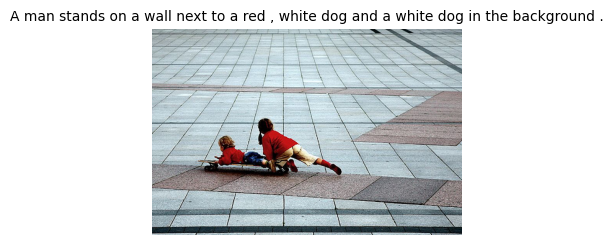

[0] generated: A man stands on a wall next to a red , white dog and a white dog in the background .


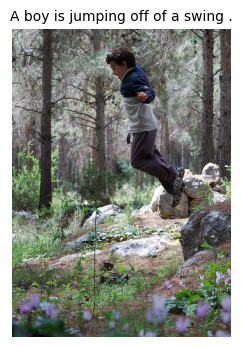

[1] generated: A boy is jumping off of a swing .


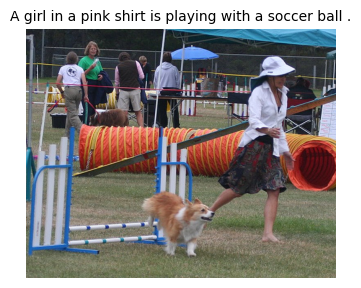

[2] generated: A girl in a pink shirt is playing with a soccer ball .


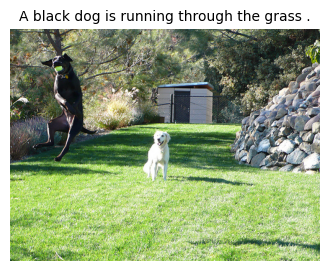

[3] generated: A black dog is running through the grass .


In [37]:
# --- Run inference on a few validation images with YOUR trained model ---
my_model = load_my_model(os.path.join(CKPT_DIR, "paligemma_tiny_final.pt"))

import matplotlib.pyplot as plt
n_show = 4
for k in range(n_show):
    row = val_split[k]
    img = row["image"]
    if not isinstance(img, Image.Image):
        img = Image.open(img)
    img = img.convert("RGB")

    caption = generate_caption(my_model, processor, img, do_sample=False, max_new_tokens=40)
    plt.figure(figsize=(4,4)); plt.imshow(img); plt.axis("off")
    plt.title(caption if caption else "(empty)", fontsize=10); plt.show()
    print(f"[{k}] generated: {caption}")

---
## 12. Caption your own image

Upload any image to the Colab/Jupyter filesystem and point to it.


In [ ]:
# In Colab:
from google.colab import files
uploaded = files.upload()

In [ ]:
image_path = next(iter(uploaded))

In [ ]:


#image_path = "your_image.jpg"   # <-- change me
if os.path.exists(image_path):
    cap = generate_caption(my_model, processor, image_path, do_sample=True,
                           temperature=0.8, top_p=0.9, max_new_tokens=40)
    print("Caption:", cap)
    display(Image.open(image_path).convert("RGB"))
else:
    print(f"Put an image at '{image_path}' and re-run this cell.")

---
## Notes & how to scale up

- **This is the same architecture as `paligemma-3b`** — every module (`Siglip*`, `Gemma*`,
  `PaliGemmaForConditionalGeneration`) is the original code. Only the **config numbers** are
  smaller and a **training path** (loss + prefix-LM mask + padding) was added.
- **To scale up** toward the real model: increase `hidden_size`, `num_hidden_layers`,
  `num_attention_heads` in `build_tiny_config` (and keep `projection_dim == text hidden_size`).
  You'll need a bigger GPU / multi-GPU and more data (COCO, Conceptual Captions, etc.).
- **Better quality on a budget:** initialize just the SigLIP vision tower from pretrained
  SigLIP and train the rest — but that's no longer "fully from scratch", which is why it's not
  the default here.
- **Checkpoints** are written to `./checkpoints/`. `paligemma_tiny_final.pt` is *your* model.
